# Publication-Ready Figures with `neuro_py`

This tutorial covers how to use `set_plotting_defaults` and `set_size` to produce figures that are correctly sized and styled for different publication workflows.

The core idea is simple:
- `set_plotting_defaults(workflow)` — sets fonts, font sizes, linewidths, and colors appropriate for the target journal or document type
- `set_size(width)` — returns figure dimensions in inches so the figure is exactly the right physical size in the final PDF, with no scaling

Used together, axis labels and tick text will render at the correct point size (e.g. 7pt for Nature) without any manual resizing.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from neuro_py.plotting.figure_helpers import set_plotting_defaults, set_size

SAVE_FIG=False

## Available Workflows

| Workflow | Font | Font Size | Target |
|----------|------|-----------|--------|
| `"nature"` | Helvetica / Arial | 7pt | Nature, Science, Cell, Neuron |
| `"word"` | Times New Roman | 11pt | Word / Google Doc manuscripts |
| `"latex"` | CMU Serif / Latin Modern | 10pt | LaTeX article submissions |

## Available Width Presets

| Preset | Width (pt) | Width (mm) | Use case |
|--------|-----------|------------|----------|
| `nature_single` | 255 | 90mm | Nature single column |
| `nature_double` | 510 | 180mm | Nature double column |
| `science_single` | 162 | 57mm | Science single column |
| `science_double` | 343 | 121mm | Science double column |
| `science_triple` | 521 | 184mm | Science full width |
| `cell_single` | 241 | 85mm | Cell/Neuron single column |
| `cell_1p5` | 323 | 114mm | Cell/Neuron 1.5 column |
| `cell_double` | 493 | 174mm | Cell/Neuron double column |
| `single_col` | 255 | 90mm | Generic single column |
| `double_col` | 510 | 180mm | Generic double column |
| `textwidth` | 418 | 147mm | LaTeX article textwidth |
| `thesis` | 427 | 151mm | Thesis textwidth |
| `beamer` | 307 | 108mm | Beamer presentation |

---
## 1. Basic Usage — Nature Workflow

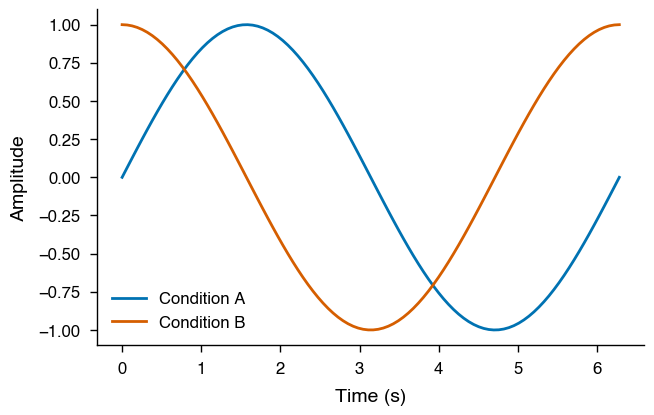

In [ ]:
set_plotting_defaults("nature")

# Single column figure sized for Nature
fig, ax = plt.subplots(figsize=set_size("nature_single"), dpi=200)

x = np.linspace(0, 2 * np.pi, 100)
ax.plot(x, np.sin(x), label="Condition A")
ax.plot(x, np.cos(x), label="Condition B")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()

if SAVE_FIG:
    fig.savefig("nature_single.svg")
plt.show()

---
## 2. Multi-Panel Figure — Double Column

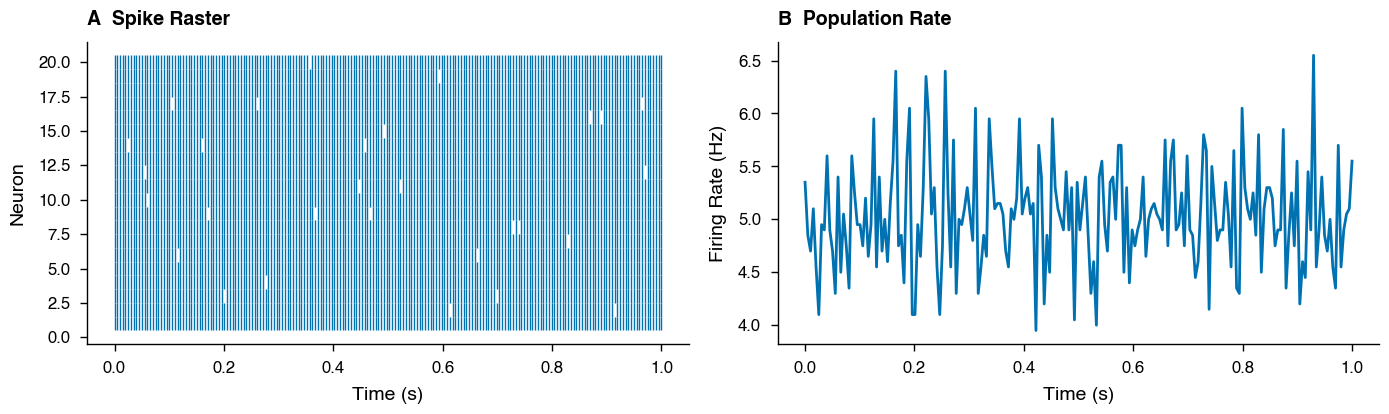

In [ ]:
set_plotting_defaults("nature")

# set_size adjusts height automatically for subplot grid
fig, axes = plt.subplots(1, 2, figsize=set_size("nature_double", subplots=(1, 2)), dpi=200)

np.random.seed(42)
t = np.linspace(0, 1, 200)
spikes = np.random.poisson(5, size=(20, 200))

# Panel A — raster plot
for i, train in enumerate(spikes):
    spike_times = t[train > 0]
    axes[0].vlines(spike_times, i + 0.5, i + 1.5, linewidth=0.5)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Neuron")
axes[0].set_title("A  Spike Raster", loc="left", fontweight="bold")

# Panel B — firing rate
rate = spikes.mean(axis=0)
axes[1].plot(t, rate)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Firing Rate (Hz)")
axes[1].set_title("B  Population Rate", loc="left", fontweight="bold")

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("nature_double_panel.svg")
plt.show()

The `subplots=(1, 2)` argument to `set_size` adjusts the figure height so that each panel has a golden ratio aspect ratio rather than the whole figure.

---
## 3. Using `fraction` — Half-Width Figures

C:\Users\Cornell\AppData\Local\Temp\ipykernel_174468\1602260718.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


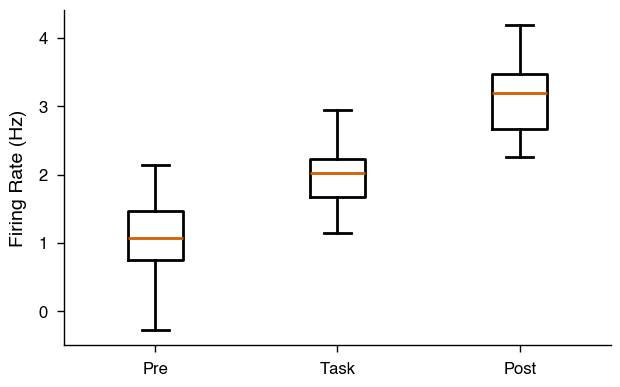

In [ ]:
set_plotting_defaults("nature")

# Half of a double column — useful for inset-style figures
fig, ax = plt.subplots(figsize=set_size("nature_double", fraction=0.5), dpi=200)

np.random.seed(0)
data = [np.random.normal(loc, 0.5, 50) for loc in [1, 2, 3]]
ax.boxplot(data, labels=["Pre", "Task", "Post"])
ax.set_ylabel("Firing Rate (Hz)")

if SAVE_FIG:
    fig.savefig("nature_half.svg")
plt.show()

---
## 4. Overriding the Aspect Ratio

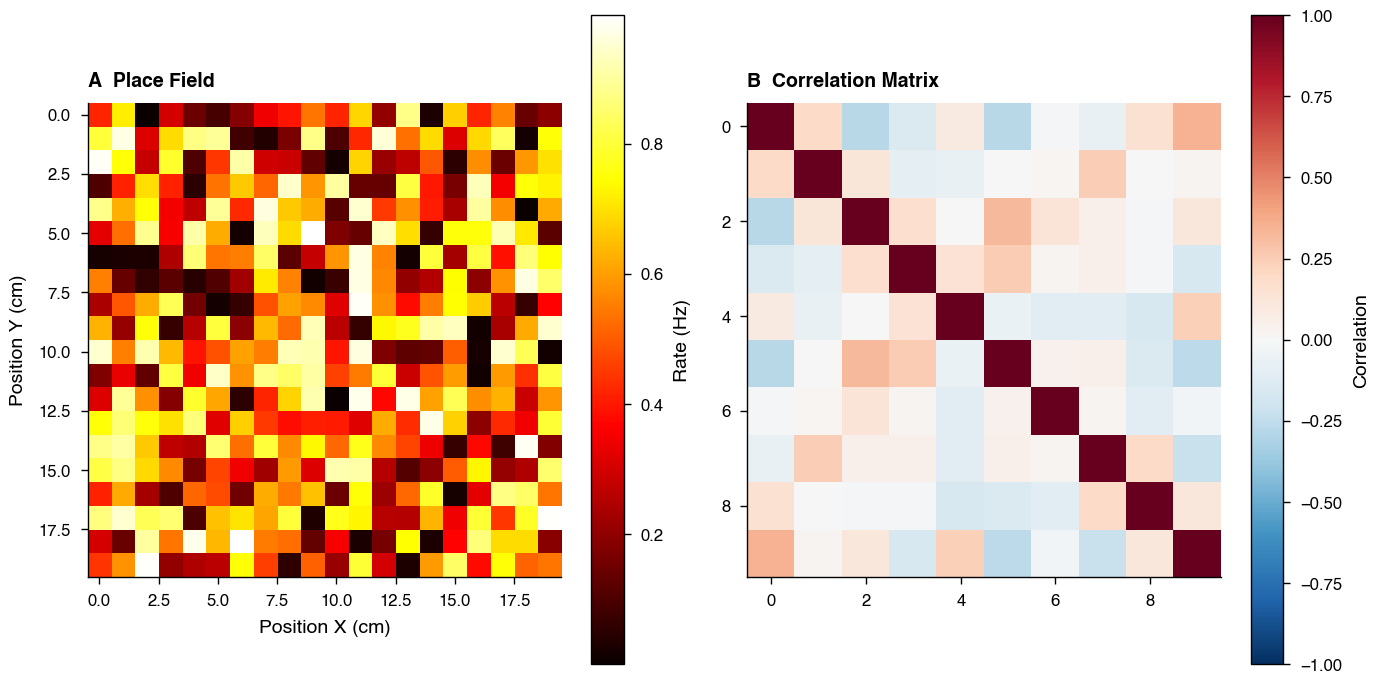

In [ ]:
set_plotting_defaults("nature")

# Square figure — useful for place field maps, correlation matrices
fig, axes = plt.subplots(1, 2, figsize=set_size("nature_double", ratio=1.0, subplots=(1, 2)), dpi=200)

np.random.seed(1)
place_field = np.random.rand(20, 20)
corr_matrix = np.corrcoef(np.random.rand(10, 50))

# Panel A — place field heatmap
im1 = axes[0].imshow(place_field, cmap="hot", aspect="equal")
axes[0].set_xlabel("Position X (cm)")
axes[0].set_ylabel("Position Y (cm)")
axes[0].set_title("A  Place Field", loc="left", fontweight="bold")
plt.colorbar(im1, ax=axes[0], label="Rate (Hz)")

# Panel B — correlation matrix
im2 = axes[1].imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
axes[1].set_title("B  Correlation Matrix", loc="left", fontweight="bold")
plt.colorbar(im2, ax=axes[1], label="Correlation")

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("nature_square.svg")
plt.show()

The default golden ratio (`~0.618`) is ideal for line plots, but `ratio=1.0` gives square panels which is better for spatial maps and matrices.

---
## 5. Word Workflow

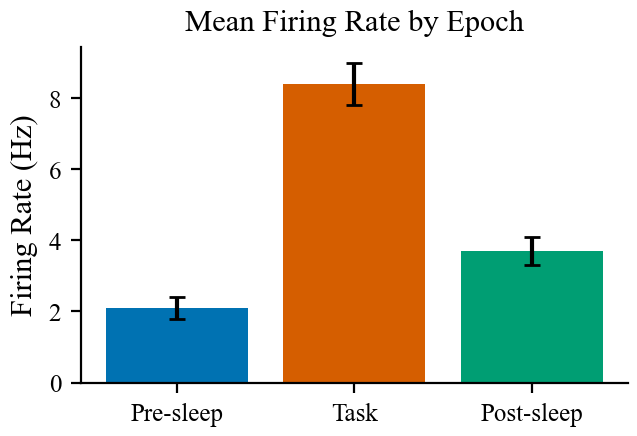

In [ ]:
set_plotting_defaults("word")

# single_col maps to nature_single width — good default for Word figures
fig, ax = plt.subplots(figsize=set_size("single_col"), dpi=200)

np.random.seed(3)
epochs = ["Pre-sleep", "Task", "Post-sleep"]
means = [2.1, 8.4, 3.7]
sems = [0.3, 0.6, 0.4]

ax.bar(epochs, means, yerr=sems, capsize=3, color=["#0072B2", "#D55E00", "#009E73"])
ax.set_ylabel("Firing Rate (Hz)")
ax.set_title("Mean Firing Rate by Epoch")

if SAVE_FIG:
    fig.savefig("word_bar.svg")
plt.show()

---
## 6. LaTeX Workflow

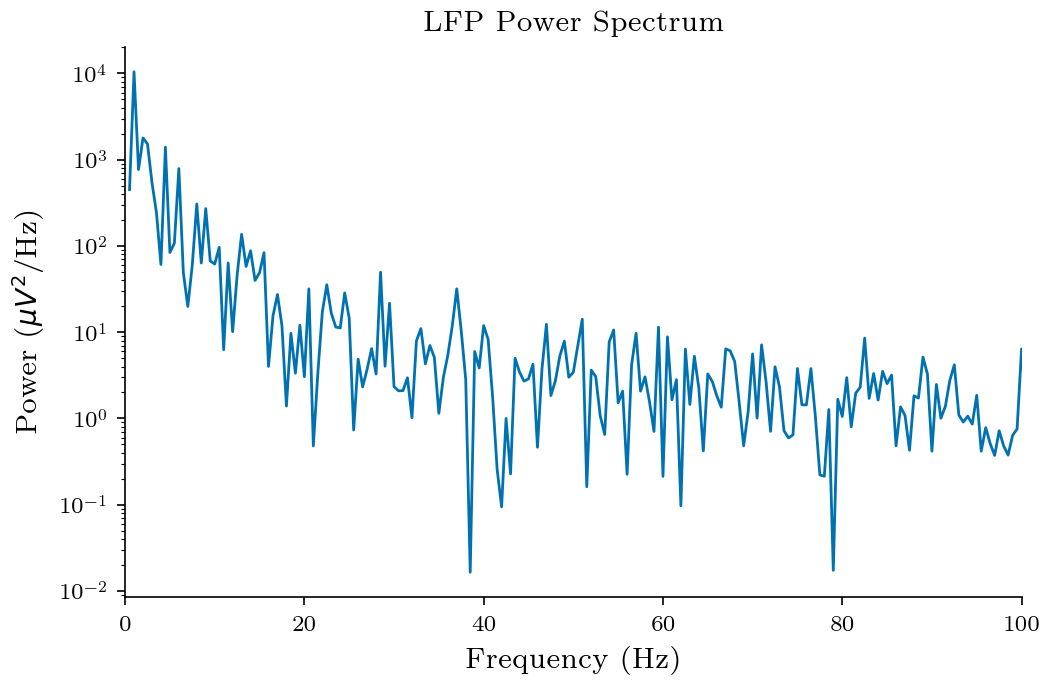

In [ ]:
set_plotting_defaults("latex")

# textwidth matches \textwidth in a standard article class document
fig, ax = plt.subplots(figsize=set_size("textwidth"), dpi=200)

np.random.seed(5)
t = np.linspace(0, 2, 500)
theta = np.cumsum(np.random.randn(500)) * 0.1
power = np.abs(np.fft.rfft(theta)) ** 2
freqs = np.fft.rfftfreq(500, d=1 / 250)

ax.semilogy(freqs[1:], power[1:])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power ($\\mu V^2$/Hz)")
ax.set_title("LFP Power Spectrum")
ax.set_xlim(0, 100)

if SAVE_FIG:
    fig.savefig("latex_spectrum.svg")
plt.show()

For half-width figures in a LaTeX document (e.g. two figures side by side with `\includegraphics[width=0.5\textwidth]`):

```python
fig, ax = plt.subplots(figsize=set_size("textwidth", fraction=0.5))
```

---
## 7. Comparing Workflows Side by Side

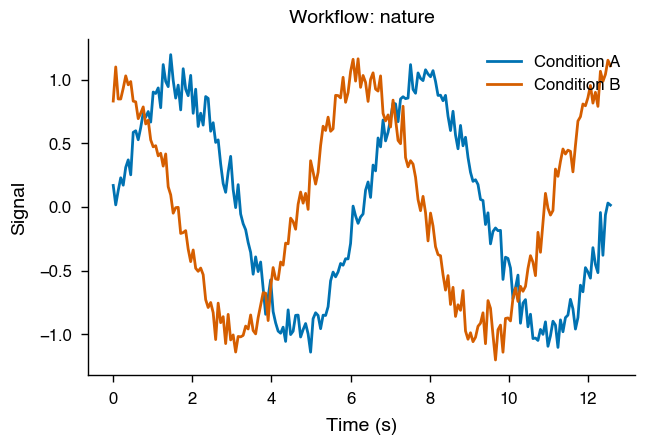

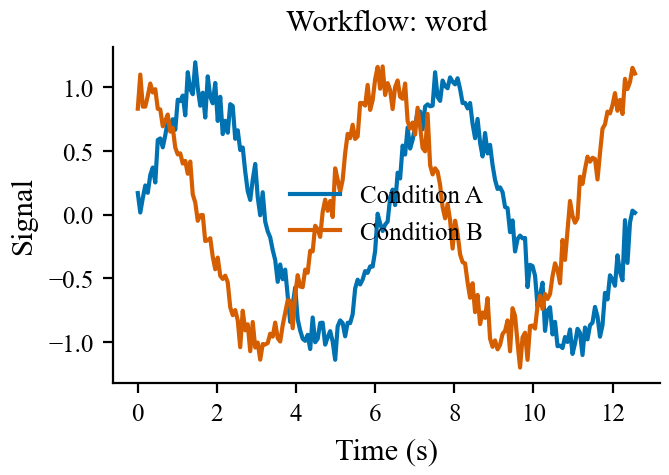

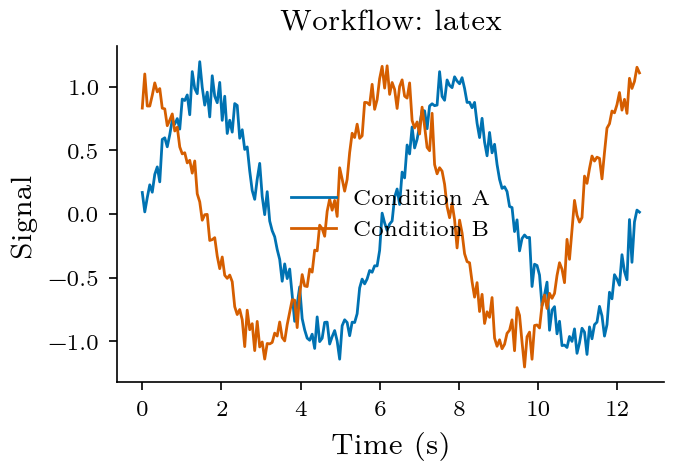

In [ ]:
np.random.seed(7)
x = np.linspace(0, 4 * np.pi, 200)
y1 = np.sin(x) + np.random.normal(0, 0.1, 200)
y2 = np.cos(x) + np.random.normal(0, 0.1, 200)

for workflow in ["nature", "word", "latex"]:
    set_plotting_defaults(workflow)
    fig, ax = plt.subplots(figsize=set_size("single_col"), dpi=200)
    ax.plot(x, y1, label="Condition A")
    ax.plot(x, y2, label="Condition B")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Signal")
    ax.set_title(f"Workflow: {workflow}")
    ax.legend()
    if SAVE_FIG:
        fig.savefig(f"compare_{workflow}.svg")
    plt.show()

---
## 8. Passing a Custom Width

If your journal has a specific column width not in the presets, pass the width in points directly. To convert from mm: `width_pt = width_mm * 2.8346`.

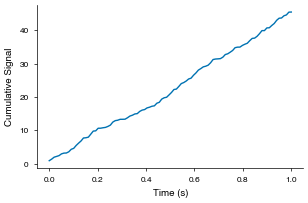

In [9]:
set_plotting_defaults("nature")

# eLife single column: 87.6mm = 248pt
elife_single_pt = 87.6 * 2.8346

fig, ax = plt.subplots(figsize=set_size(elife_single_pt))
ax.plot(np.linspace(0, 1, 100), np.random.rand(100).cumsum())
ax.set_xlabel("Time (s)")
ax.set_ylabel("Cumulative Signal")

plt.show()

---
## Summary

```python
# Typical Nature/Cell/Neuron/Science figure
set_plotting_defaults("nature")
fig, ax = plt.subplots(figsize=set_size("nature_single"))

# Multi-panel — height adjusts automatically
fig, axes = plt.subplots(2, 3, figsize=set_size("nature_double", subplots=(2, 3)))

# Square panels for heatmaps/place fields
fig, ax = plt.subplots(figsize=set_size("nature_single", ratio=1.0))

# Half-width figure
fig, ax = plt.subplots(figsize=set_size("nature_double", fraction=0.5))

# LaTeX article
set_plotting_defaults("latex")
fig, ax = plt.subplots(figsize=set_size("textwidth"))

# Word/Google Doc
set_plotting_defaults("word")
fig, ax = plt.subplots(figsize=set_size("single_col"))
```